CUSTOMER CHURN ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Imported necessary python libraries

In [2]:
df = pd.read_csv("CustomerChurn.csv")
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1936.30,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,107.70,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1903.50,No


In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [4]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce")
for i in range(0,len(df)):
    df.loc[i,'TotalCharges']=(df.loc[i,"tenure"]*df.loc[i,"MonthlyCharges"])
if ((df["tenure"]*df["MonthlyCharges"])==df['TotalCharges']).all():
    print("True")
else:
    print("False")

True


In [6]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1936.30,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,107.70,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1903.50,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,141.40,Yes


In [7]:
print(df['PaymentMethod'].unique())
print(df['Contract'].unique())
print(df['tenure'].min())
print(df['tenure'].max())

['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
['Month-to-month' 'One year' 'Two year']
1
72


In [8]:
df = df.drop(df[df['tenure'] == 0].index, axis=0)

In [9]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")
df["OnlineSecurity"] = df["OnlineSecurity"].replace("No internet service", "No")
df["OnlineBackup"] = df["OnlineBackup"].replace("No internet service", "No")
df["DeviceProtection"] = df["DeviceProtection"].replace("No internet service", "No")
df["TechSupport"] = df["TechSupport"].replace("No internet service", "No")
df["StreamingTV"] = df["StreamingTV"].replace("No internet service", "No")
df["StreamingMovies"] = df["StreamingMovies"].replace("No internet service", "No")

In [10]:
df.to_csv("CustomerChurn.csv", index=False)

Total: 7032
Yes: 73.42%, 5163
 No: 26.58%, 1869


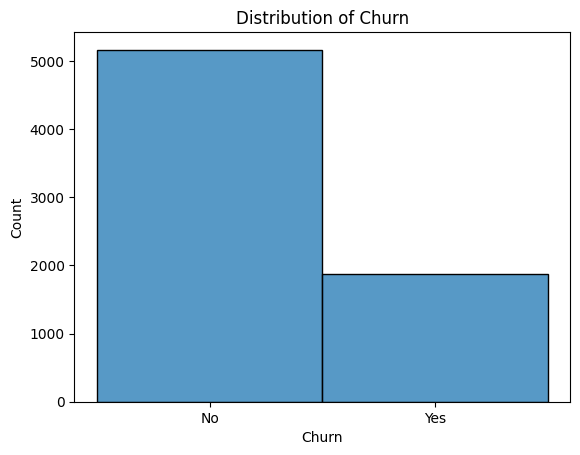

In [11]:
total = len(df['Churn'])
x,y = df['Churn'].value_counts()
print(f"Total: {total}")
print(f"Yes: {(x/total)*100:.2f}%, {x}")
print(f" No: {(y/total)*100:.2f}%, {y}")
sns.histplot(data=df, x='Churn')
plt.title("Distribution of Churn")
plt.show()

In [14]:
print(df["MultipleLines"].value_counts())
print(df["PhoneService"].value_counts())
print(df["InternetService"].value_counts())
print(df["OnlineSecurity"].value_counts())

MultipleLines
No     4065
Yes    2967
Name: count, dtype: int64
PhoneService
Yes    6352
No      680
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64
OnlineSecurity
No     5017
Yes    2015
Name: count, dtype: int64
